# 04 - Train TF-IDF + Naive Bayes

Notebook nay train model baseline cho bai toan sentiment analysis.

Pipeline:

1. Doc `clean_reviews.csv`
2. Chia train/test
3. Chuyen text thanh vector bang TF-IDF
4. Train Multinomial Naive Bayes
5. Danh gia model
6. Luu model va vectorizer

## Buoc 1 - Import thu vien

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Buoc 2 - Khai bao duong dan

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_reviews.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

print("Clean data path:", CLEAN_DATA_PATH)
print("Clean file exists:", CLEAN_DATA_PATH.exists())

Clean data path: c:\Users\ADMIN\Downloads\Documents\DS\Project\data\processed\clean_reviews.csv
Clean file exists: True


## Buoc 3 - Doc du lieu da lam sach

In [3]:
df = pd.read_csv(CLEAN_DATA_PATH)
df["review_clean"] = df["review_clean"].fillna("")

print("So dong:", df.shape[0])
print("So cot:", df.shape[1])

df.head()

So dong: 9219
So cot: 4


,Review,Rating,review_clean,sentiment
0,"The ambience was good, food was quite good . h...",5,the ambience was good food was quite good had ...,Positive
1,Ambience is too good for a pleasant evening. S...,5,ambience is too good for a pleasant evening se...,Positive
2,A must try.. great food great ambience. Thnx f...,5,a must try great food great ambience thnx for ...,Positive
3,Soumen das and Arun was a great guy. Only beca...,5,soumen das and arun was a great guy only becau...,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5,food is good we ordered kodi drumsticks and ba...,Positive


## Buoc 4 - Tach input X va label y

- `X`: text da lam sach
- `y`: nhan sentiment can du doan

In [4]:
X = df["review_clean"]
y = df["sentiment"]

print("So mau X:", X.shape[0])
print("So nhan y:", y.shape[0])

y.value_counts()

So mau X: 9219
So nhan y: 9219


sentiment
Positive    5671
Negative    2385
Neutral     1163
Name: count, dtype: int64

## Buoc 5 - Chia train/test

Dung 80% du lieu de train va 20% de test. `stratify=y` giu ty le sentiment gan giong nhau o train va test.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain sentiment ratio:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest sentiment ratio:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 7375
Test size: 1844

Train sentiment ratio:
sentiment
Positive    0.615
Negative    0.259
Neutral     0.126
Name: proportion, dtype: float64

Test sentiment ratio:
sentiment
Positive    0.615
Negative    0.259
Neutral     0.126
Name: proportion, dtype: float64


## Buoc 6 - Vector hoa text bang TF-IDF

Model khong doc truc tiep text. TF-IDF chuyen moi review thanh vector so.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (7375, 5000)
Test TF-IDF shape: (1844, 5000)


## Buoc 7 - Train Multinomial Naive Bayes

In [7]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Buoc 8 - Du doan tren tap test

In [8]:
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

array(['Negative', 'Positive', 'Positive', 'Negative', 'Positive',
       'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
      dtype='<U8')

## Buoc 9 - Danh gia bang Accuracy va Classification Report

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8221

              precision    recall  f1-score   support

    Negative       0.80      0.86      0.83       477
     Neutral       0.56      0.02      0.04       233
    Positive       0.83      0.97      0.90      1134

    accuracy                           0.82      1844
   macro avg       0.73      0.62      0.59      1844
weighted avg       0.79      0.82      0.77      1844



## Buoc 10 - Tao bang ket qua danh gia

In [10]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

report_df

,precision,recall,f1-score,support
Negative,0.803150,0.855346,0.828426,477.000000
Neutral,0.555556,0.021459,0.041322,233.000000
Positive,0.831198,0.972663,0.896384,1134.000000
accuracy,0.822126,0.822126,0.822126,0.822126
macro avg,0.729968,0.616489,0.588711,1844.000000
weighted avg,0.789114,0.822126,0.770763,1844.000000


## Buoc 11 - Confusion Matrix

In [11]:
label_order = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(y_test, y_pred, labels=label_order)

cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
cm_df

,Negative,Neutral,Positive
Negative,408,3,66
Neutral,70,5,158
Positive,30,1,1103


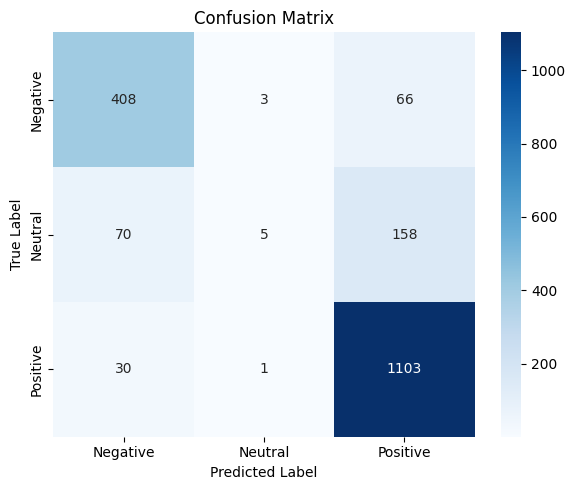

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Buoc 12 - Thu du doan review moi

In [13]:
sample_reviews = [
    "The food was amazing and the staff were very friendly.",
    "The restaurant was okay, not bad but not special.",
    "The food was cold and the service was terrible.",
]

sample_vectors = vectorizer.transform(sample_reviews)
sample_predictions = model.predict(sample_vectors)

pd.DataFrame({
    "review": sample_reviews,
    "predicted_sentiment": sample_predictions,
})

,review,predicted_sentiment
0,The food was amazing and the staff were very f...,Positive
1,"The restaurant was okay, not bad but not special.",Neutral
2,The food was cold and the service was terrible.,Negative


## Buoc 13 - Luu model, vectorizer va ket qua

In [14]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODELS_DIR / "naive_bayes_model.joblib")
joblib.dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.joblib")
report_df.to_csv(REPORTS_DIR / "classification_report.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.close()

print("Da luu model vao:", MODELS_DIR)
print("Da luu report vao:", REPORTS_DIR)
print("Da luu confusion matrix vao:", FIGURES_DIR)

Da luu model vao: c:\Users\ADMIN\Downloads\Documents\DS\Project\models
Da luu report vao: c:\Users\ADMIN\Downloads\Documents\DS\Project\reports
Da luu confusion matrix vao: c:\Users\ADMIN\Downloads\Documents\DS\Project\figures


## Ket luan nhanh

- TF-IDF + Multinomial Naive Bayes la baseline don gian, phu hop cho phan loai text.
- Vi du lieu lech ve `Positive`, can doc ky F1-score tung lop va confusion matrix.
- Neu lop `Neutral` co ket qua thap, day la han che co the neu trong bao cao.